In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans, DBSCAN

# 1 - EDA

                        Nomber  Percentage
CREDIT_LIMIT                 1    0.011173
CUST_ID                      0    0.000000
PURCHASES                    0    0.000000
BALANCE                      0    0.000000
ONEOFF_PURCHASES             0    0.000000
INSTALLMENTS_PURCHASES       0    0.000000
CASH_ADVANCE                 0    0.000000
PAYMENTS                     0    0.000000


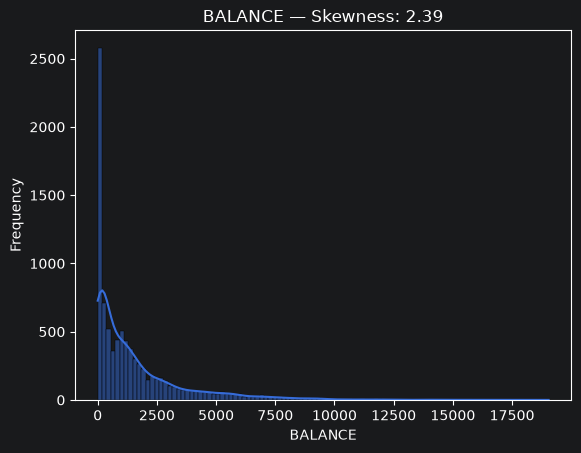

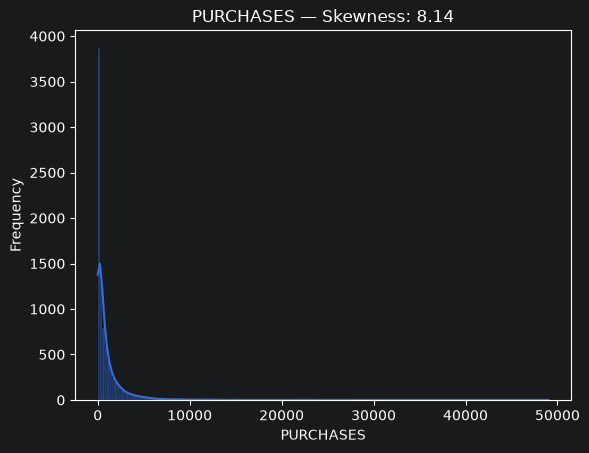

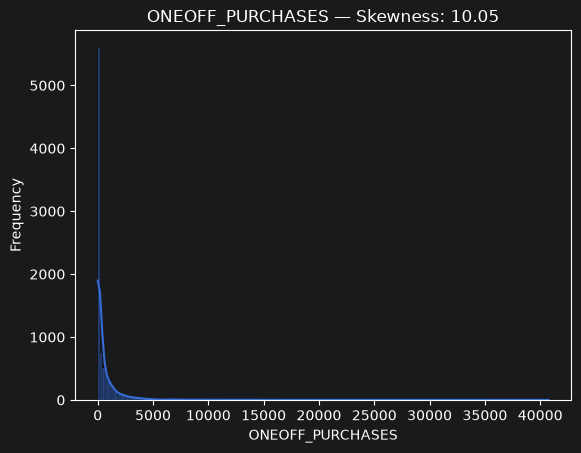

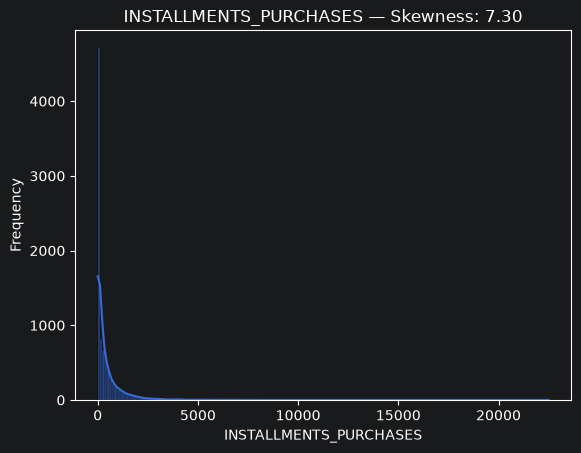

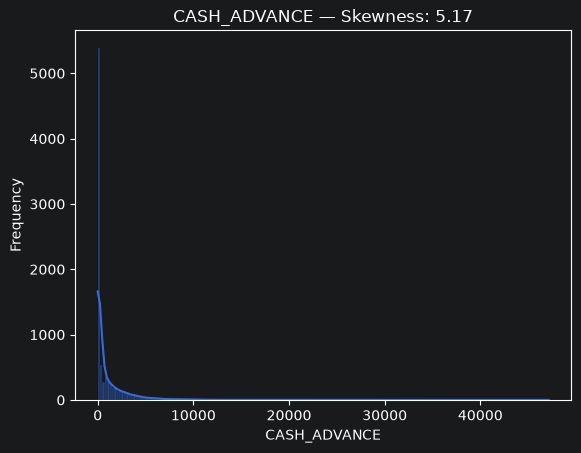

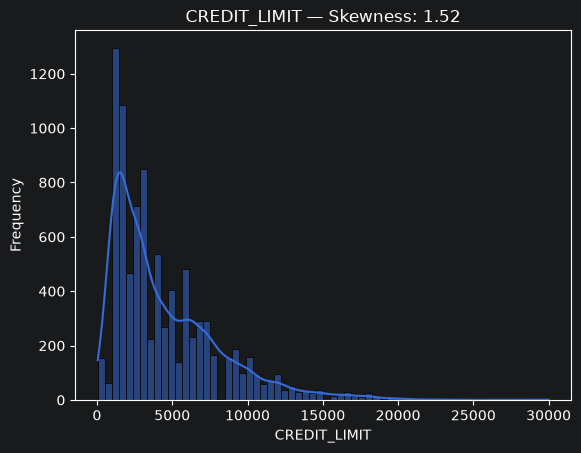

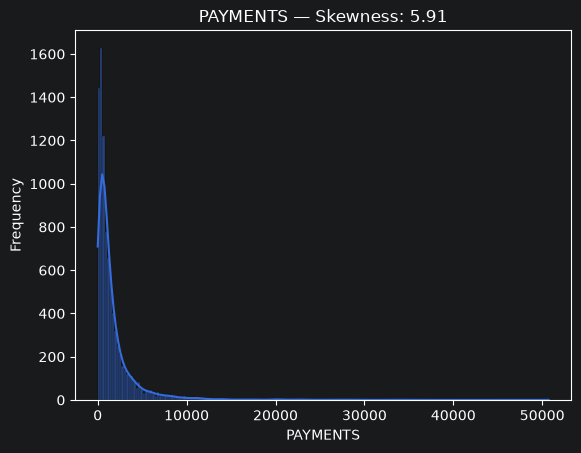

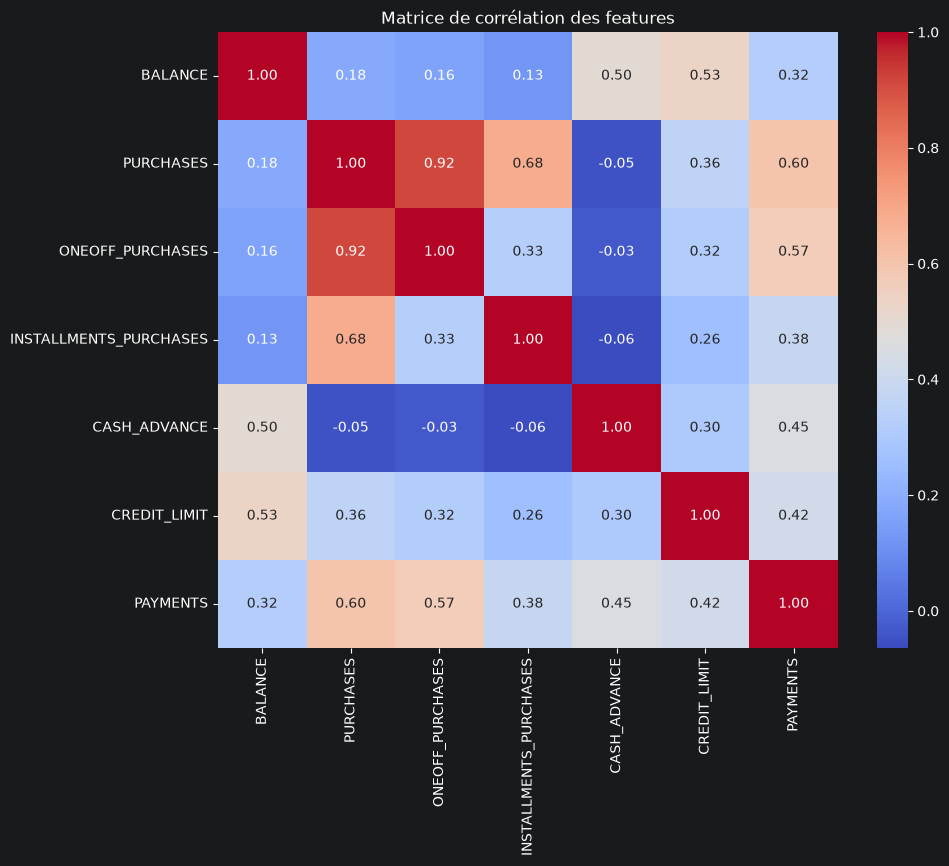

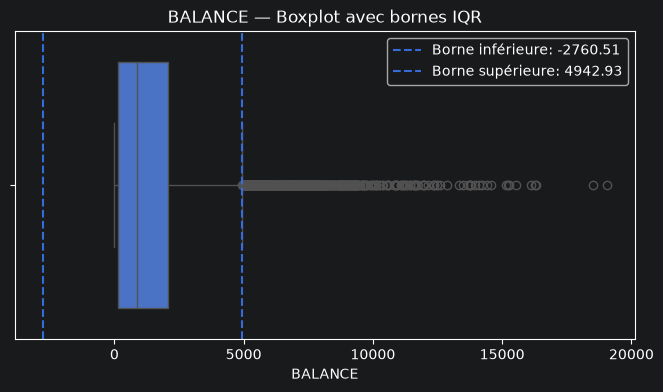

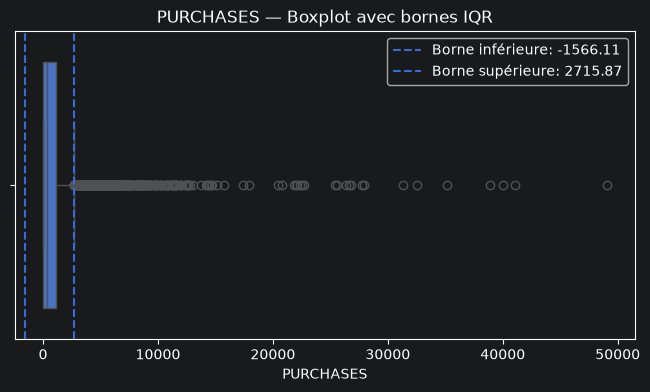

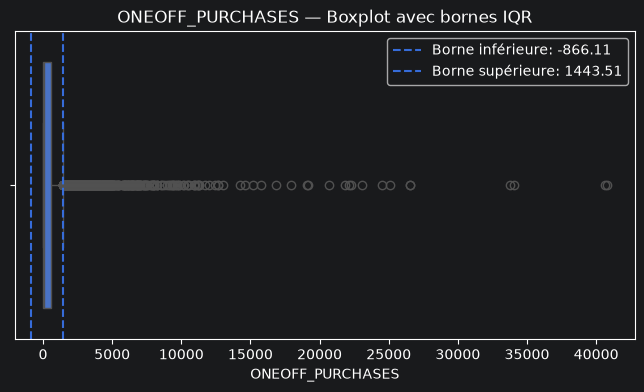

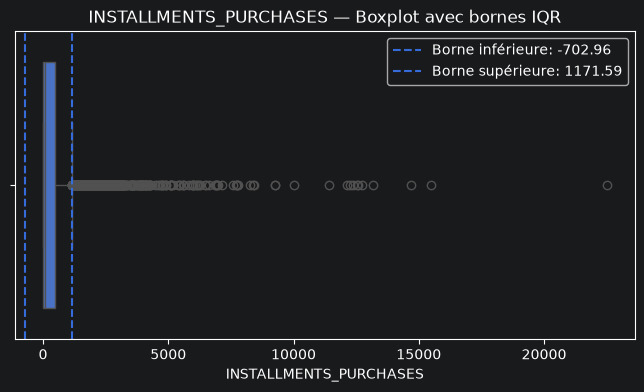

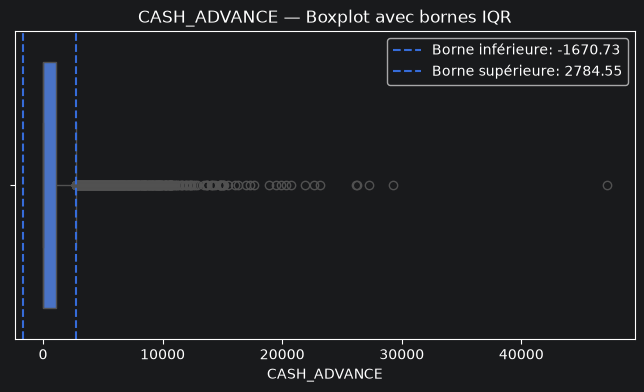

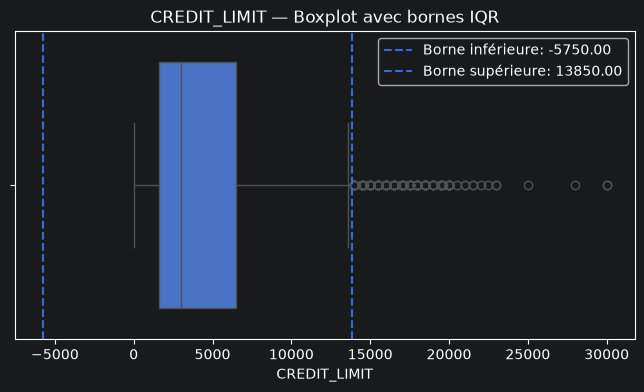

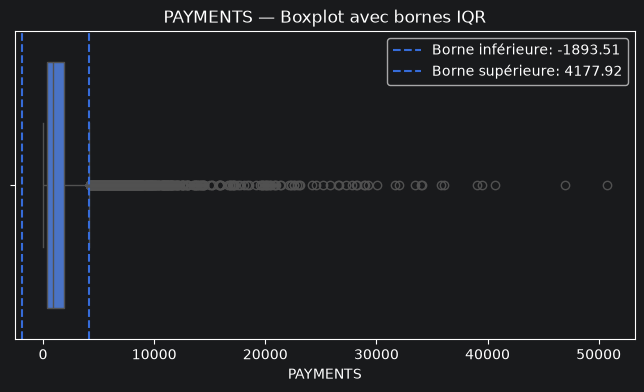

In [7]:
df_clean = pd.read_csv('https://raw.githubusercontent.com/hajjajihamza/brief-3/refs/heads/main/data/row/dataset.csv')

# === duplicated ===
df_clean[df_clean.duplicated()]

# === Messing Values ===
df_clean.describe()
df_clean[df_clean['CREDIT_LIMIT'].isna()]

# === tableau récapitulatif des valeurs manquantes ===
missing_table= pd.DataFrame({
    'Nomber': df_clean.isna().sum(),
    'Percentage': df_clean.isna().mean() * 100
}).sort_values(by='Percentage', ascending=False)

print(missing_table)

# ============ Visualization ============
# === 1-Histograms ===
columns = df_clean.columns.tolist()
columns.remove('CUST_ID')

for column in columns:
    skewness = df_clean[column].skew()

    sns.histplot(df_clean[column], kde=True)
    plt.title(f'{column} — Skewness: {skewness:.2f}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

# === 2-Corrélations ===
correlation_matrix = df_clean[columns].corr()
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matrice de corrélation des features')
plt.show()

# === 3-Boxplot ===
for column in columns:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df_clean[column])

    plt.axvline(
        lower_bound,
        linestyle='--',
        label=f'Borne inférieure: {lower_bound:.2f}'
    )

    plt.axvline(
        upper_bound,
        linestyle='--',
        label=f'Borne supérieure: {upper_bound:.2f}'
    )

    plt.title(f'{column} — Boxplot avec bornes IQR')
    plt.xlabel(column)
    plt.legend()

    plt.show()

# 2 -Cleaning

In [8]:
# supprimr les line due quntine des value aberrantes
df_clean = df_clean.dropna(axis=0)

# suprimer les colonnes inutiles
df_clean = df_clean.drop(columns=['CUST_ID']).reset_index(drop=True)

#  sauvegarder le data frame cleaning
# df_clean.to_csv('data/processed/df_clean.csv', index=False)

# 2 - Preprocessing

In [9]:
# Copy dataset pour clustering
df_prepare_clustering = df_clean.copy()

# les column de dataset
columns = df_clean.columns.tolist()

### Transform logarithmique

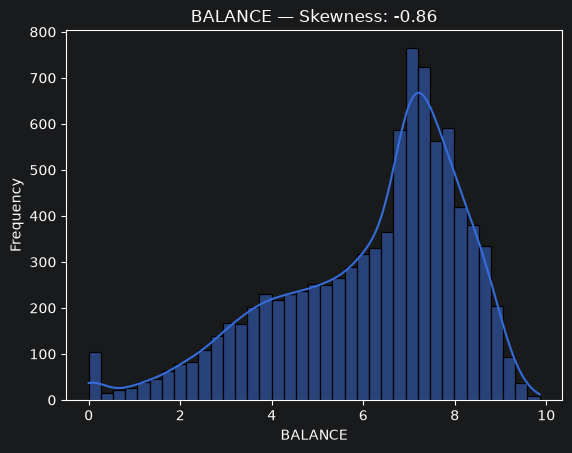

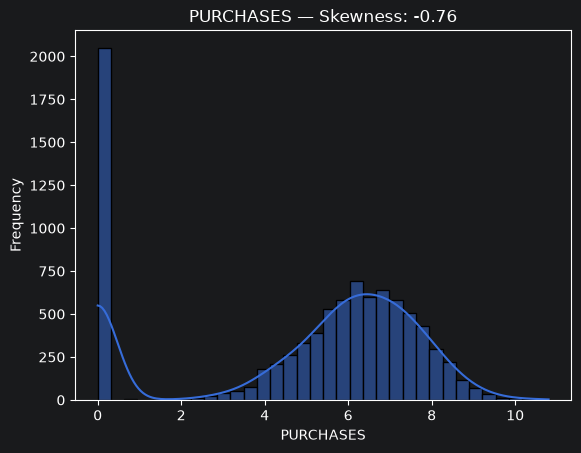

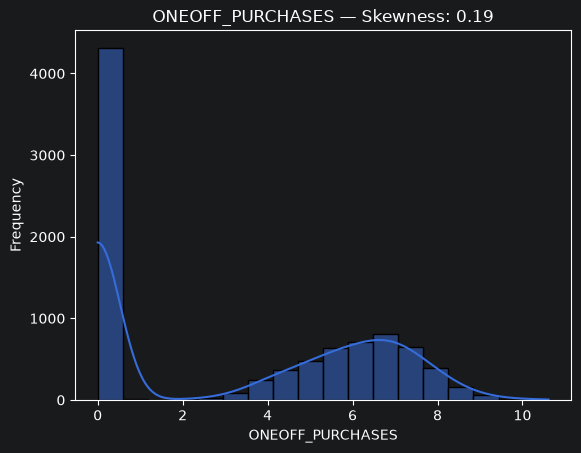

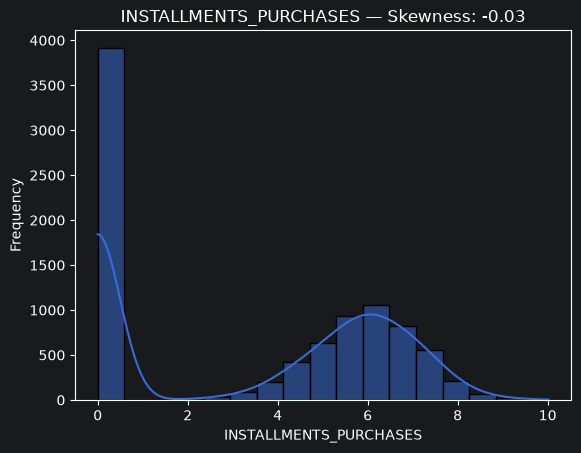

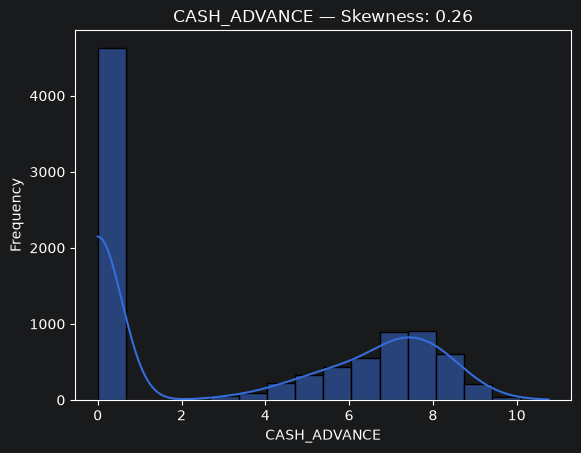

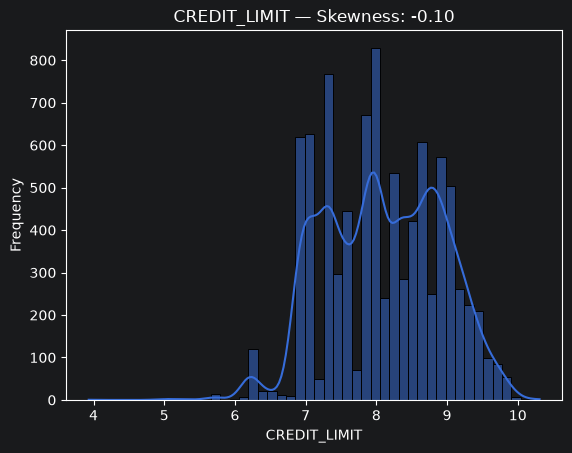

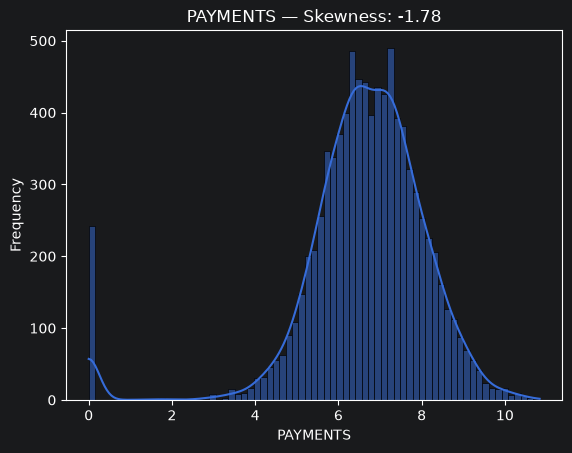

In [10]:
for column in columns:
    df_prepare_clustering[column] = np.log1p(df_prepare_clustering[column])

# Visualisation
for column in columns:
    skewness = df_prepare_clustering[column].skew()

    sns.histplot(df_prepare_clustering[column], kde=True)
    plt.title(f'{column} — Skewness: {skewness:.2f}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

### Transform Standard Scaler

In [11]:
scaler = StandardScaler()
df_prepare_clustering[columns] = scaler.fit_transform(df_prepare_clustering[columns])

### PCA

[35.36236764 29.25854648 11.39698084 10.0053658 ]
[35.36236764 64.62091411 76.01789495 86.02326076]


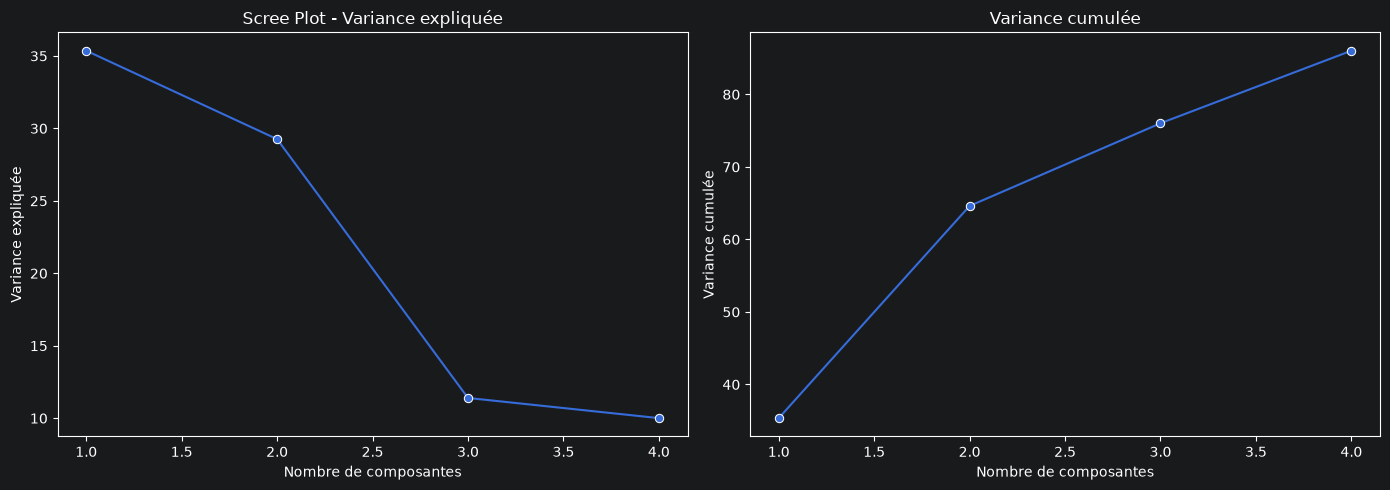

In [12]:
pca = PCA(n_components=4)
X_pca = pca.fit_transform(df_prepare_clustering)

# === Variance expliquée
variance_expliquee = pca.explained_variance_ratio_ * 100
print(variance_expliquee)

# === Variance cumulée
variance_cumulee = variance_expliquee.cumsum()
print(variance_cumulee)

# === Visualisation (Scree plot) ===

_, [axe_1,axe_2] = plt.subplots(1, 2, figsize=(14, 5)) # Création de 2 subplots

# === Variance expliquée
sns.lineplot(
    x= range(1 , len(variance_expliquee) + 1),
    y = variance_expliquee,
    marker='o',
    ax=axe_1
)

axe_1.set_title("Scree Plot - Variance expliquée")
axe_1.set_xlabel("Nombre de composantes")
axe_1.set_ylabel("Variance expliquée")

# === Variance cumulée
sns.lineplot(
    x= range(1, len(variance_cumulee) + 1),
    y= variance_cumulee,
    marker='o',
    ax=axe_2
)

axe_2.set_title("Variance cumulée")
axe_2.set_xlabel("Nombre de composantes")
axe_2.set_ylabel("Variance cumulée")

plt.tight_layout()
plt.show()

# ==============
# Le meilleur k (n_composant) est 4
# ==============

# 3 - Algorithms clustering

### K-Means

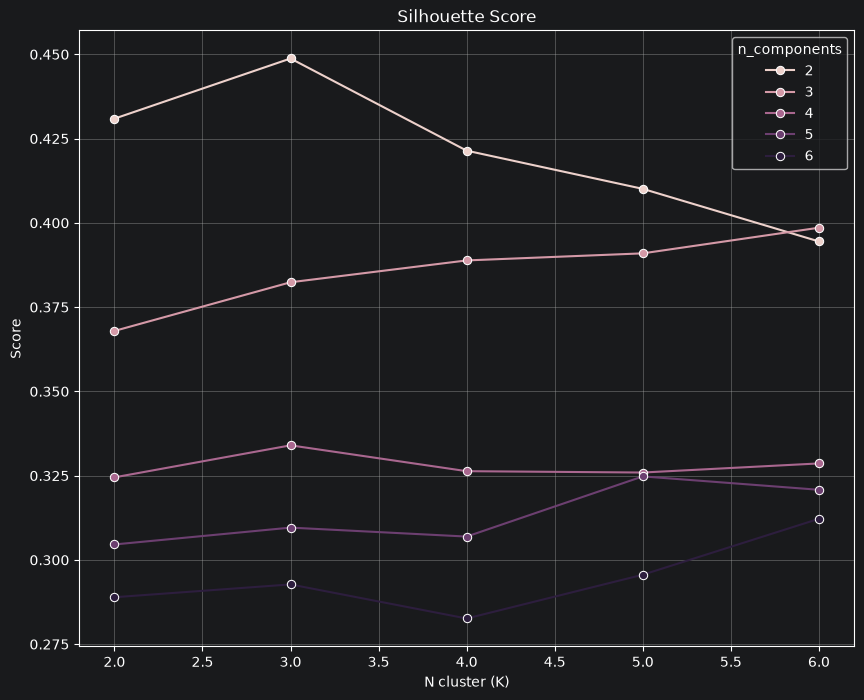

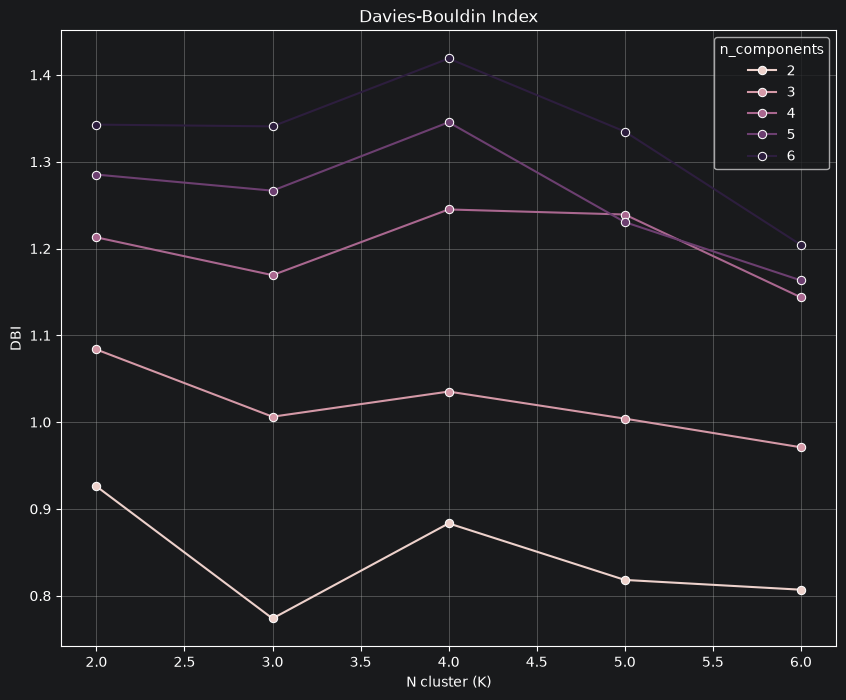

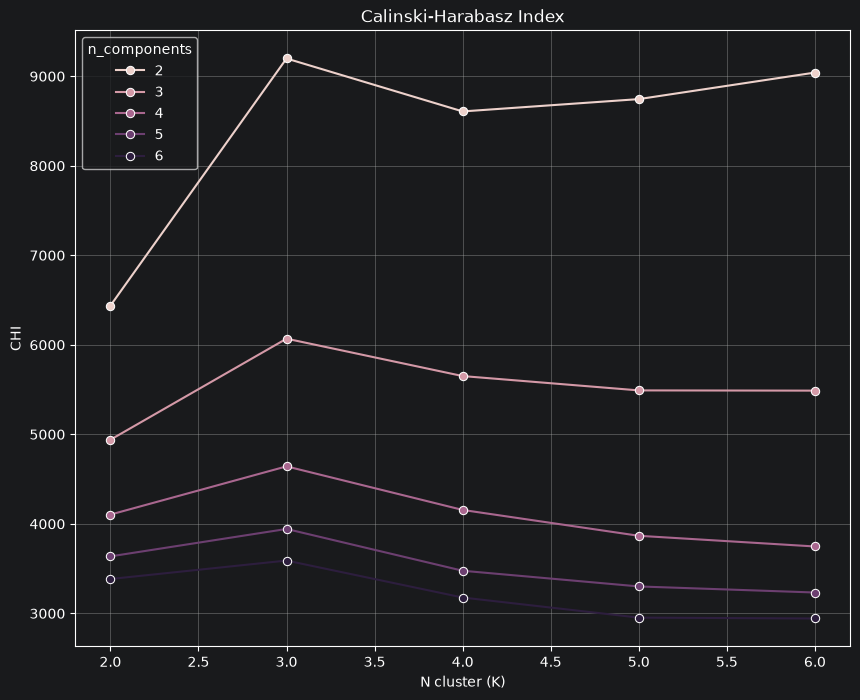

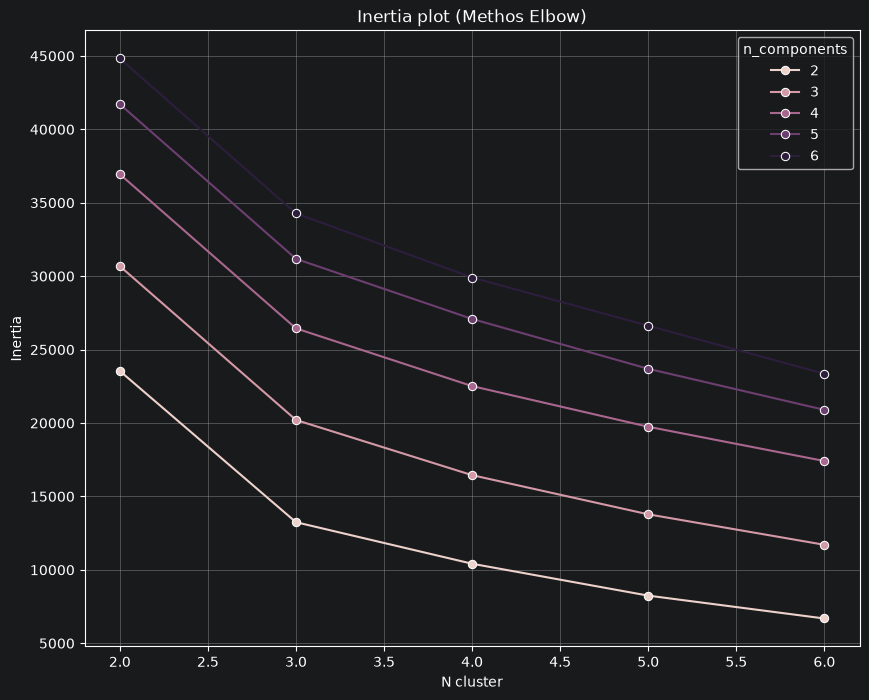

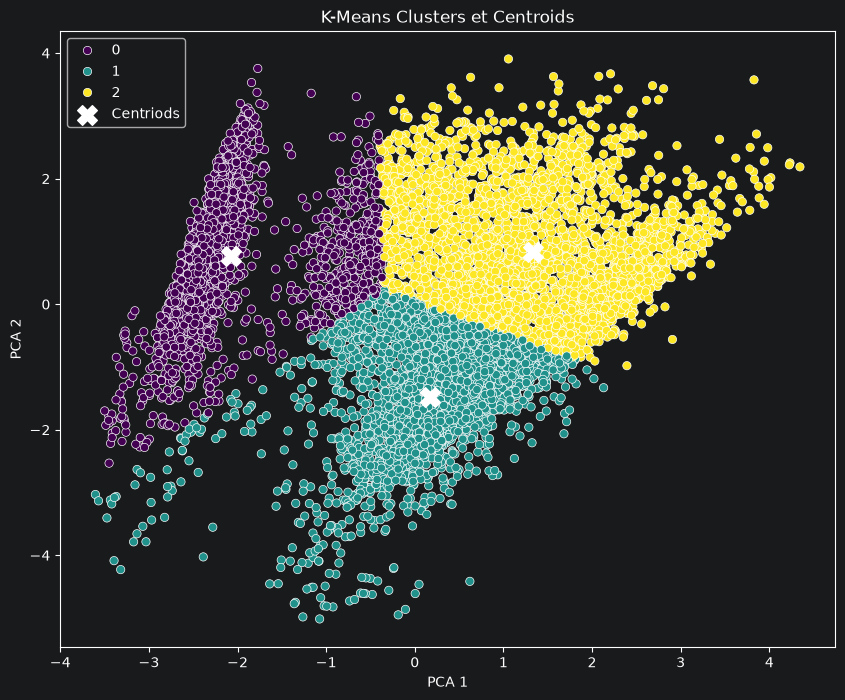

In [13]:
results_kmeans = []

for n_components in range(2, 7):
    pca = PCA(n_components)
    X_pca = pca.fit_transform(df_prepare_clustering)

    for k in range(2, 7):
        kmeans = KMeans(
            n_clusters=k,
            init='k-means++',
            n_init=10,
            max_iter=300,
            random_state=26
        )

        clusters = kmeans.fit_predict(X_pca)

        results_kmeans.append({
            'n_components': n_components,
            'n_clusters': k,
            'inertia': kmeans.inertia_,
            'silhouette': silhouette_score(X_pca, clusters),
            'DBI': davies_bouldin_score(X_pca, clusters),
            'CHI': calinski_harabasz_score(X_pca, clusters)
        })

df_results_kmeans = pd.DataFrame(results_kmeans).sort_values(by=['silhouette', 'DBI', 'CHI'], ascending=[False, True, False])

# === Visualisation de la silhouette
plt.figure(figsize=(10, 8))
sns.lineplot(
    data=df_results_kmeans,
    x='n_clusters',
    y='silhouette',
    marker='o',
    hue='n_components',
)
plt.xlabel('N cluster (K)')
plt.ylabel('Score')
plt.title('Silhouette Score')
plt.grid(True)
plt.show()

# === Visualisation de Davies-Bouldin Index
plt.figure(figsize=(10, 8))
sns.lineplot(
    data=df_results_kmeans,
    x='n_clusters',
    y='DBI',
    marker='o',
    hue='n_components',
)
plt.xlabel('N cluster (K)')
plt.ylabel('DBI')
plt.title('Davies-Bouldin Index')
plt.grid(True)
plt.show()

# === Visualisation de Calinski-Harabasz Index
plt.figure(figsize=(10, 8))
sns.lineplot(
    data=df_results_kmeans,
    x='n_clusters',
    y='CHI',
    marker='o',
    hue='n_components',
)
plt.xlabel('N cluster (K)')
plt.ylabel('CHI')
plt.title('Calinski-Harabasz Index')
plt.grid(True)
plt.show()

# === Visualisation de inertia
plt.figure(figsize=(10,8))
sns.lineplot(
    data=df_results_kmeans,
    x='n_clusters',
    y='inertia',
    hue='n_components',
    marker='o'
)
plt.xlabel('N cluster')
plt.ylabel('Inertia')
plt.title('Inertia plot (Methos Elbow)')
plt.grid(True)
plt.show()

meilleur_result_kmeans = df_results_kmeans.loc[df_results_kmeans['silhouette'].idxmax()]
# ==============
# Le meilleur k (n_composant) est 2
# Le meilleur k (n_cluster) est 3
# ==============

# === PCA final
pca_kmeans = PCA(n_components=int(meilleur_result_kmeans['n_components']))
X_pca_kmeans = pca_kmeans.fit_transform(df_prepare_clustering)

# === Model final
kmeans = KMeans(
    n_clusters=int(meilleur_result_kmeans['n_clusters']),
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=26
)

df_clean['cluster_kmeans'] = kmeans.fit_predict(X_pca_kmeans)

# === Vérifier qu'aucun cluster n'est inférieur à environ 10%;
pd.Series(df_clean.groupby('cluster_kmeans').size() / df_clean.shape[0] * 100).reset_index(name='percentage')

# === Visualisation de clusters
plt.figure(figsize=(10,8))
sns.scatterplot(
    x=X_pca_kmeans[:,0],
    y=X_pca_kmeans[:,1],
    hue=df_clean['cluster_kmeans'],
    palette="viridis"
)
# Centroids
plt.scatter(
    x=kmeans.cluster_centers_[:, 0],
    y=kmeans.cluster_centers_[:, 1],
    marker='X',
    color='white',
    label='Centriods',
    s=200
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('K-Means Clusters et Centroids')
plt.legend()
plt.show()

### DBSCAN

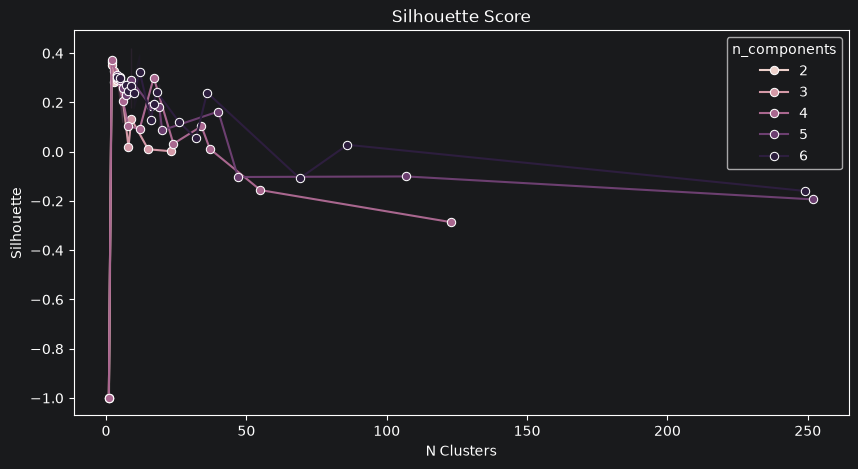

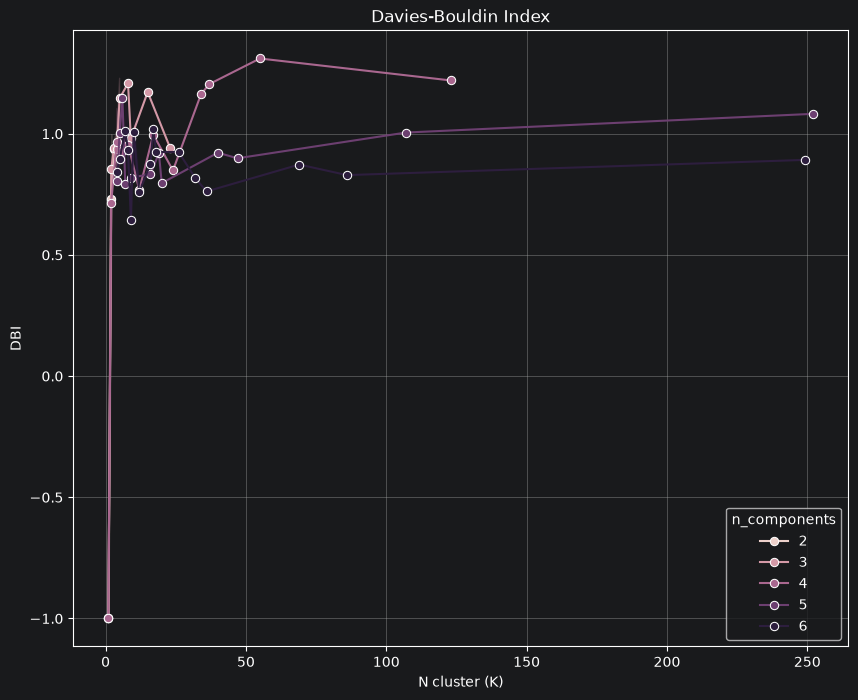

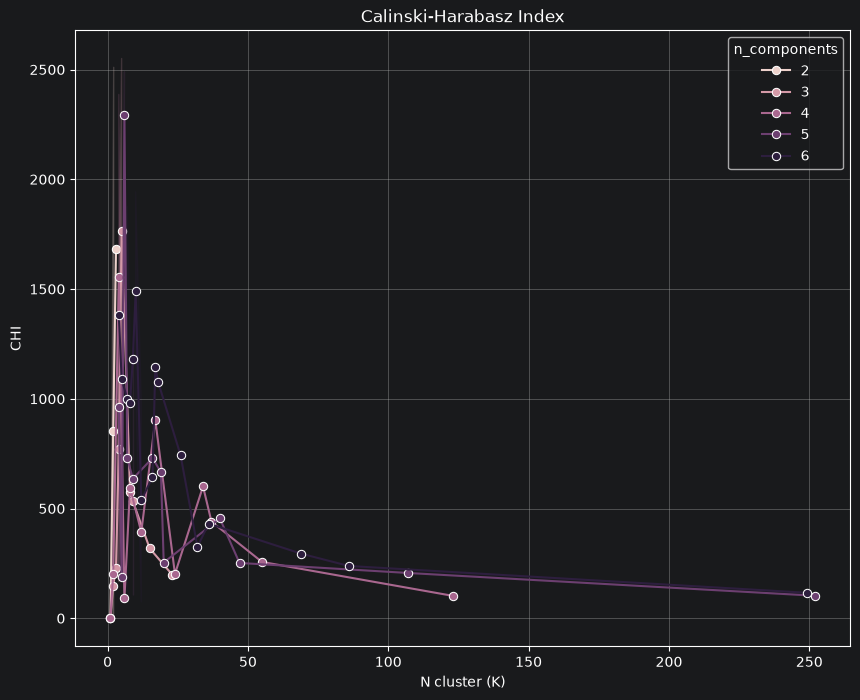

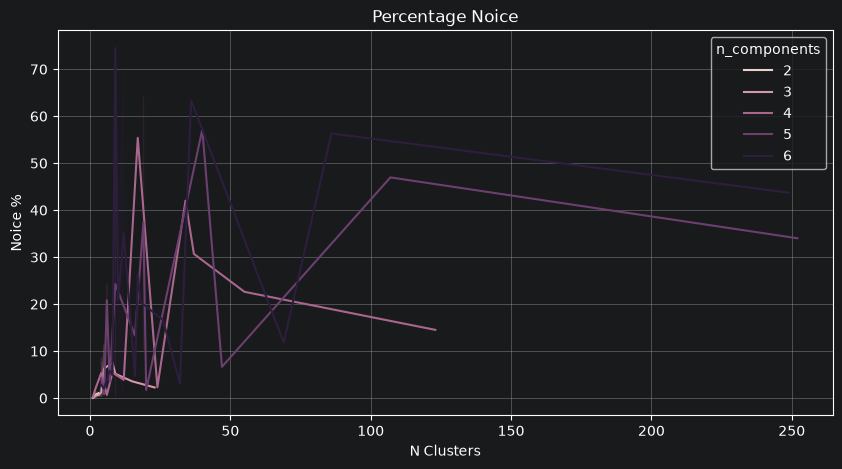

In [136]:
results_dbscan = []

eps_values = [0.3, 0.5, 0.7, 1]
min_samples_values = [3, 5, 7, 10, 15]

for n_components in range(2, 7):
    pca = PCA(n_components)
    x_pca = pca.fit_transform(df_prepare_clustering)
    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps= eps, min_samples=min_samples)
            clusters = pd.Series(dbscan.fit_predict(x_pca))

            mask_not_noice = clusters != -1
            mask_noice = clusters == -1

            # Nomber de cluster dans bruit (-1)
            n_clusters = clusters[mask_not_noice].unique().size

            # Percentage de bruit
            percentage_noice = clusters[mask_noice].size / len(clusters) * 100

            # Calculer la silhouette
            if n_clusters >= 2:
                silhouette = silhouette_score(X_pca[mask_not_noice], clusters[mask_not_noice])
                dbi = davies_bouldin_score(X_pca[mask_not_noice], clusters[mask_not_noice])
                chi = calinski_harabasz_score(X_pca[mask_not_noice], clusters[mask_not_noice])
            else:
                silhouette = -1
                dbi = -1
                chi = -1

            results_dbscan.append({
                'n_components': n_components,
                'eps': eps,
                'min_samples': min_samples,
                'percentage_noice': percentage_noice,
                'n_clusters': n_clusters,
                'silhouette': silhouette,
                'DBI': dbi,
                'CHI': chi
            })

df_results_dbscan = pd.DataFrame(results_dbscan).sort_values(by=['silhouette', 'DBI', 'CHI'], ascending=[False, True, False])
# === Visualisation de la silhouette
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df_results_dbscan,
    x='n_clusters',
    y='silhouette',
    marker='o',
    hue='n_components'
)
plt.xlabel('N Clusters')
plt.ylabel('Silhouette')
plt.title('Silhouette Score')
plt.show()

# === Visualisation de Davies-Bouldin Index
plt.figure(figsize=(10, 8))
sns.lineplot(
    data=df_results_dbscan,
    x='n_clusters',
    y='DBI',
    marker='o',
    hue='n_components',
)
plt.xlabel('N cluster (K)')
plt.ylabel('DBI')
plt.title('Davies-Bouldin Index')
plt.grid(True)
plt.show()

# === Visualisation de Calinski-Harabasz Index
plt.figure(figsize=(10, 8))
sns.lineplot(
    data=df_results_dbscan,
    x='n_clusters',
    y='CHI',
    marker='o',
    hue='n_components',
)
plt.xlabel('N cluster (K)')
plt.ylabel('CHI')
plt.title('Calinski-Harabasz Index')
plt.grid(True)
plt.show()

# === Visualisation de bruit
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df_results_dbscan,
    x='n_clusters',
    y='percentage_noice',
    markers=['o'],
    hue='n_components'
)
plt.xlabel('N Clusters')
plt.ylabel('Noice %')
plt.title('Percentage Noice')
plt.grid(True)
plt.show()


meilleur_result_dbscan = df_results_dbscan.loc[df_results_dbscan['silhouette'].idxmax()]
# ==============
# Le meilleur k (n_composant) est 5
# Le meilleur k (n_cluster) est 9
# Le percentage de bruit est 1.061%
# ==============

# === PCA final
pca_dbscan = PCA(n_components=int(meilleur_result_dbscan['n_components']))
X_pca_dbscan = pca_dbscan.fit_transform(df_prepare_clustering)

# === DBSCAN final
dbscan  = DBSCAN(
    eps= meilleur_result_dbscan['eps'],
    min_samples= int(meilleur_result_dbscan['min_samples'])
)
df_clean['cluster_dbscan'] = dbscan.fit_predict(X_pca_dbscan)
df_clean['est_atypique_dbscan'] = np.where(df_clean['cluster_dbscan'] == -1, True, False)

# === Vérifier qu'aucun cluster n'est inférieur à environ 10%;
print(df_clean.groupby('cluster_dbscan')['cluster_dbscan'].size() / df_clean.shape[0]  * 100)

### Comparer K-means et DBSCAN

In [180]:
meilleur_result_kmeans['method'] = 'k-means'
meilleur_result_dbscan["method"] = 'dbscan'
meilleur_result = pd.DataFrame(
    [
        meilleur_result_kmeans[['method', 'n_components', 'n_clusters', 'silhouette', 'DBI', 'CHI']].to_dict(),
        meilleur_result_dbscan[['method', 'n_components', 'n_clusters', 'silhouette', 'DBI', 'CHI', 'percentage_noice']].to_dict()
    ]
).sort_values(by=['silhouette', 'DBI', 'CHI'], ascending=[False, True, False])
print(meilleur_result)

# Donc methos final est (K-means)

df_clean['cluster_final'] = df_clean['cluster_kmeans']

    method  n_components  n_clusters  silhouette       DBI          CHI  \
0  k-means           2.0         3.0    0.448762  0.773727  9198.513187   
1   dbscan           5.0         9.0    0.421158  0.668448  1235.455867   

   percentage_noice  
0               NaN  
1         69.728461  


# 4 - Profiling

#### Standardisé

In [16]:
df_prepare_clustering['cluster'] = df_clean['cluster_kmeans']
df_prepare_clustering.groupby('cluster').mean()


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
cluster,,,,,,,
0,0.494748,-1.402608,-0.797624,-1.022620,1.003185,-0.122259,-0.006169
1,-0.876122,0.243039,-0.326868,0.276471,-0.751310,-0.557722,-0.611125
2,0.454823,0.780755,0.873665,0.477519,-0.024899,0.602890,0.569022


### Réel

In [18]:
df_clean.groupby('cluster_kmeans').mean()

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
cluster_kmeans,,,,,,,
0,2175.614633,23.795076,19.032997,4.812170,2008.002664,3981.359083,1630.352088
1,331.738844,467.019741,149.561833,318.025717,53.064421,2691.753643,560.867351
2,2265.797889,2200.839838,1412.748663,788.323441,1096.821018,6527.656023,2890.359261
